In [24]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
import ast
import seaborn as sns
import matplotlib.pyplot as plt 
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error


df = pd.read_csv('../data/movies.csv')

threshold = df["revenue"].quantile(0.75)

df["success"] = (df["revenue"] >= threshold).astype(int)
# print(df.iloc[3000]["genres"])

Genre One-Hot Encoding

In [25]:
# One-Hot Encoding

df["genres_parsed"] = df["genres"].apply(ast.literal_eval)
df["genre_names"] = df["genres_parsed"].apply(lambda x: [d["name"] for d in x])

mlb = MultiLabelBinarizer()
encoded = mlb.fit_transform(df["genre_names"])

encoded_df = pd.DataFrame(encoded, columns=mlb.classes_)
df = pd.concat([df, encoded_df], axis=1)
# print(df.iloc[3000]["genre_names"])

Top Actors in Movie

In [26]:
cols = df.columns.to_list()
print(cols)

from collections import Counter

df["cast_parsed"] = df["cast"].apply(ast.literal_eval)
df["actor_names"] = df["cast_parsed"].apply(lambda x: [d["name"] for d in x])
all_actors = [actor for sublist in df["actor_names"] for actor in sublist]

actor_counts = Counter(all_actors)
top_10_actors = actor_counts.most_common(10)
print(top_10_actors)


['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'movie_id', 'cast', 'crew', 'success', 'genres_parsed', 'genre_names', 'Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
[('Samuel L. Jackson', 67), ('Robert De Niro', 57), ('Bruce Willis', 51), ('Matt Damon', 48), ('Morgan Freeman', 46), ('Steve Buscemi', 43), ('Liam Neeson', 41), ('Johnny Depp', 40), ('Owen Wilson', 40), ('John Goodman', 39)]


Top 10 Actors

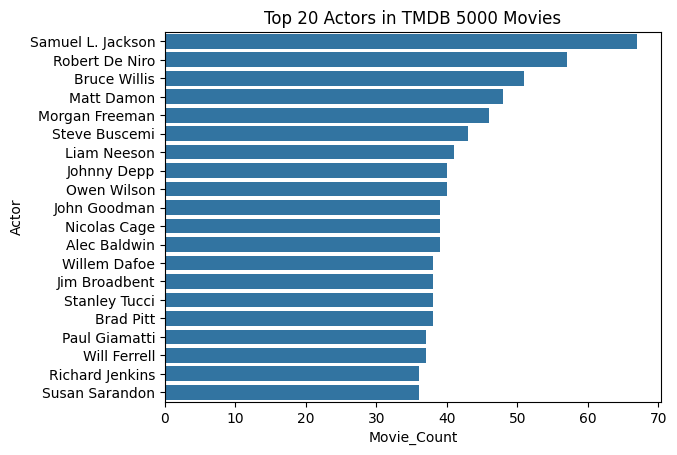

In [27]:
top_actors_df = pd.DataFrame(actor_counts.most_common(20), columns=["Actor", "Movie_Count"])

sns.barplot(data=top_actors_df, x="Movie_Count", y="Actor")
plt.title("Top 20 Actors in TMDB 5000 Movies")
plt.show()

In [28]:
top_20_actors = [name[0] for name in actor_counts.most_common(20)]
df["num_top_actors"] = df["actor_names"].apply(
    lambda actors: sum(1 for actor in actors if actor in top_20_actors)
)
# print(df.iloc[1]["num_top_actors"])
# print(df["num_top_actors"])
# print(df.iloc[3]["cast"])
# df[["original_title", "actor_names", "num_top_actors"]].head()
# print(df.iloc[3]["actor_names"])

In [29]:
df["release_date"] = pd.to_datetime(df["release_date"])
df["release_month"] = df["release_date"].dt.month
df["release_year"] = df["release_date"].dt.year

features_of_interest = ["budget", "release_month", "release_year", "num_top_actors"] # predict revenue

In [ ]:
models = {
    "Linear Regression": LogisticRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    )
}

Logistic Regression - Predicting Success<br>
  
Predicting if a given movie will be successful (top 25% revenue) based on budget amount, release month, release year, the featured top actors, and genre category.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

genres = list(mlb.classes_)

features_of_interest = ["budget", "release_month", "release_year", "num_top_actors"] + genres
df.fillna(0, inplace=True)

X = df[features_of_interest]
y = df["success"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

predictions = model.predict(X_test_scaled)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89       696
           1       0.78      0.54      0.64       266

    accuracy                           0.83       962
   macro avg       0.81      0.74      0.76       962
weighted avg       0.82      0.83      0.82       962



/var/folders/_v/0d3shdb10bvb1sp09bm59gzw0000gn/T/ipykernel_64193/564542947.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df.fillna(0, inplace=True)


Random Forest Regressor - Predicting Revenue<br>

Predict the Revenue of a movie based on budget amount, release month, release year, the featured top actors, and genre category.

In [31]:
X = df[features_of_interest]
y = df["revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()

model.fit(X_train, y_train)

preds = model.predict(X_test)

print(mean_absolute_error(y_test, preds))

58883365.27017892


Feature Importance<br> 

Which factors define the success of a movie?

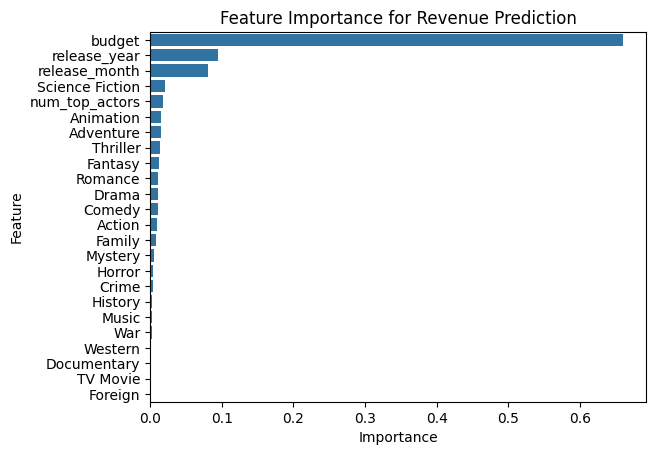

In [32]:
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance for Revenue Prediction")
plt.show()